# VNNLib Fuzzing with ACTFuzzer

Inference-based whitebox fuzzing on CIFAR-100 VNNLib benchmarks to find counterexamples.

In [1]:
# Setup and imports
import sys, os
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import torch
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
import logging
# Configure logging: suppress verbose INFO logs from vnnlib_loader
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)
# Force reload all fuzzing modules to pick up latest changes
import importlib
modules_to_reload = [
    'act.pipeline.fuzzing.mutations',
    'act.pipeline.fuzzing.coverage',
    'act.pipeline.fuzzing.corpus',
    'act.pipeline.fuzzing.checker',
    'act.pipeline.fuzzing.actfuzzer',
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
    'act.front_end.vnnlib_loader.vnnlib_parser',
    'act.front_end.vnnlib_loader.onnx_converter',
    'act.front_end.vnnlib_loader.data_model_loader',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.fuzzing.actfuzzer import ACTFuzzer, FuzzingConfig

# CIFAR-100 class names (100 fine-grained classes)
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("✓ Setup complete (modules reloaded with batch dimension fixes)")


[ACT] Auto-detecting project root: ..
[WARN] Gurobi license not found: ../modules/gurobi/gurobi.lic
[INFO] Please place gurobi.lic in: ../modules/gurobi
✓ Setup complete (modules reloaded with batch dimension fixes)


## Load VNNLib Benchmark and Run Fuzzing (1-minute budget)

**Note on VNNLib Property Format:**
- VNNLib benchmarks encode robustness as: `Y_i >= Y_true` for all i ≠ true
- This means: "all wrong classes must have logits ≥ true class logit"
- A **counterexample** (violation) occurs when the model predicts a different class (misclassification)
- The fuzzer tries to find inputs within ε that cause misclassification


In [ ]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

# Load VNNLib instances
creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=20,
    validate_shapes=True
)
print(f"✓ Loaded {len(spec_results)} instances\n")

# Randomly select 3 instances for fuzzing
import random
num_seeds = 3
random_indices = random.sample(range(len(spec_results)), min(num_seeds, len(spec_results)))
print(f"🎲 Randomly selected {len(random_indices)} instances: {[i+1 for i in random_indices]}\n")

selected_instances = [spec_results[i] for i in random_indices]
# selected_instances = spec_results[:2]
# Synthesize wrapped models for all selected instances
# Note: synthesize_models_from_specs returns (wrapped_models, reports) tuple
print("Synthesizing wrapped models for selected instances...")
wrapped_models, reports = synthesize_models_from_specs(selected_instances)
print(f"✓ Models wrapped for {len(wrapped_models)} instances\n")

# Load fuzzing config from YAML with overrides (using from_yaml pattern)
config = FuzzingConfig.from_yaml(
    timeout_seconds=60.0,  # 1 minute per instance
    device="cuda" if torch.cuda.is_available() else "cpu",
    output_dir=Path("fuzzing_results_vnnlib"),
    # ============================================================================
    # 🔍 TRACING ENABLED: Capture fuzzing execution traces for analysis
    # ============================================================================
    trace_level=1,           # 1=default (strategies, coverage), 2=full (+ input snapshots)
    trace_sample_rate=10,     # Capture every iteration (1=all, 10=every 10th, etc.)
    trace_storage="json",    # Storage format: "json" or "hdf5"
    trace_output=None        # Auto-generate path in output_dir/traces.json
    # All other settings (max_iterations, mutation_weights, etc.) loaded from config.yaml
)

print(f"Fuzzing config: timeout={config.timeout_seconds}s per instance, device={config.device}")
print(f"Mutation weights: {config.mutation_weights}")
print(f"🔍 Tracing: ENABLED (level={config.trace_level}, storage={config.trace_storage})\n")

print("="*80)
print("STARTING FUZZING - ONE MODEL PER INSTANCE")
print("="*80)

# Fuzz each wrapped model independently
all_reports = []
all_fuzzers = []  # Store all fuzzers to access their corpus seeds
instance_info = []
trace_files = []  # Store trace file paths for each instance

for idx, (combo_id, wrapped_model) in enumerate(wrapped_models.items()):
    # Extract labeled input from model's InputLayer
    input_layer = wrapped_model[0]  # First layer is InputLayer
    labeled_input = input_layer.labeled_input  # LabeledInputTensor
    
    # Extract input spec from InputSpecLayer (second layer)
    input_spec_layer = wrapped_model[1]  # Second layer is InputSpecLayer
    input_spec = input_spec_layer.spec  # Access .spec attribute
    epsilon = float((input_spec.ub - input_spec.lb).max())
    
    # Extract output spec from OutputSpecLayer (last layer)
    output_spec_layer = wrapped_model[-1]  # Last layer is OutputSpecLayer
    output_spec = output_spec_layer.spec  # Access .spec attribute
    
    print(f"\n[{idx+1}/{len(wrapped_models)}] Instance: {combo_id}")
    print(f"   True label: {labeled_input.label} ({CIFAR100_CLASSES[labeled_input.label]})")
    print(f"   Epsilon: {epsilon:.6f}")
    
    # Store instance info for visualization
    instance_info.append({
        'index': idx,
        'input_tensor': labeled_input.tensor,
        'true_label': labeled_input.label,
        'epsilon': epsilon,
        'input_spec': input_spec,
        'combo_id': combo_id
    })
    
    # Run fuzzing with this model's stored input as seed
    fuzzer = ACTFuzzer(
        wrapped_model=wrapped_model,
        initial_seeds=[labeled_input],
        config=config
    )
    report = fuzzer.fuzz()
    all_reports.append(report)
    all_fuzzers.append(fuzzer)  # Store fuzzer for this instance
    
    # Store trace file path if tracing is enabled (FIXED: use fuzzer.tracer.output_path)
    if hasattr(fuzzer, 'tracer') and fuzzer.tracer is not None:
        trace_file_path = fuzzer.tracer.output_path
        trace_files.append(trace_file_path)
        print(f"   📊 Trace saved: {trace_file_path}")
    
    print(f"   ✓ Iterations: {report.total_iterations}, "
          f"Time: {report.total_time:.2f}s, "
          f"Counterexamples: {len(report.counterexamples)}")

# Aggregate results
print("\n" + "="*80)
print("AGGREGATED RESULTS")
print("="*80)
report = type('Report', (), {
    'total_iterations': sum(r.total_iterations for r in all_reports),
    'total_time': sum(r.total_time for r in all_reports),
    'counterexamples': [ce for r in all_reports for ce in r.counterexamples],
    'neuron_coverage': sum(r.neuron_coverage for r in all_reports) / len(all_reports),
    'total_mutations': sum(r.total_mutations for r in all_reports),
    'seeds_explored': sum(r.seeds_explored for r in all_reports)
})()

LOADING CIFAR-100 VNNLIB BENCHMARK
✓ Loaded 20 instances

🎲 Randomly selected 3 instances: [7, 4, 9]

Synthesizing wrapped models for selected instances...

🧬 Synthesizing models from 3 spec result(s)...
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3673_sidx_32_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4141_sidx_5393_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3767_sidx_7124_eps_0.0039: Created 1 wrapped model(s)

🎉 Synthesized 3 wrapped models from specs!
✓ Models wrapped for 3 instances

Fuzzing config: timeout=60.0s per instance, device=cpu
Mutation weights: {'gradient': 0, 'pgd': 0.4, 'activation': 0.3, 'boundary': 0.2, 'random': 0.1}
🔍 Tracing: ENABLED (level=1, storage=json)

STARTING FUZZING - ONE MODEL PER INSTANCE

[1/3] Instance: m:CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3673_sidx_32_eps_0.0039|x:c

## Visualize Results


FUZZING SUMMARY
  Iterations: 5707 (31.7 it/s)
  Time: 180.14s
  Seeds explored: 11
  Neuron coverage: 56.70%
  Counterexamples: 0

ORIGINAL INPUTS ANALYSIS
Instance 1: True=streetcar, Pred=streetcar (0.559) ✓ Correct
Instance 2: True=plate, Pred=plate (0.611) ✓ Correct
Instance 3: True=lion, Pred=lion (0.305) ✓ Correct

SPECIFICATION SUMMARY

Instance 1 - streetcar:
  InputSpec:
    Kind: BOX
    Shape: torch.Size([1, 3, 32, 32])
    Epsilon (L∞): 0.030590
    Range: [-1.5304, 2.0250]
  VNNLib Property:
    Robustness check: Y_i >= Y_81 for all i ≠ 81
    Meaning: Model should predict 'streetcar' for all inputs within ε=0.030590

Instance 2 - plate:
  InputSpec:
    Kind: BOX
    Shape: torch.Size([1, 3, 32, 32])
    Epsilon (L∞): 0.030590
    Range: [-1.8971, 1.2864]
  VNNLib Property:
    Robustness check: Y_i >= Y_61 for all i ≠ 61
    Meaning: Model should predict 'plate' for all inputs within ε=0.030590

Instance 3 - lion:
  InputSpec:
    Kind: BOX
    Shape: torch.Size([1, 3, 

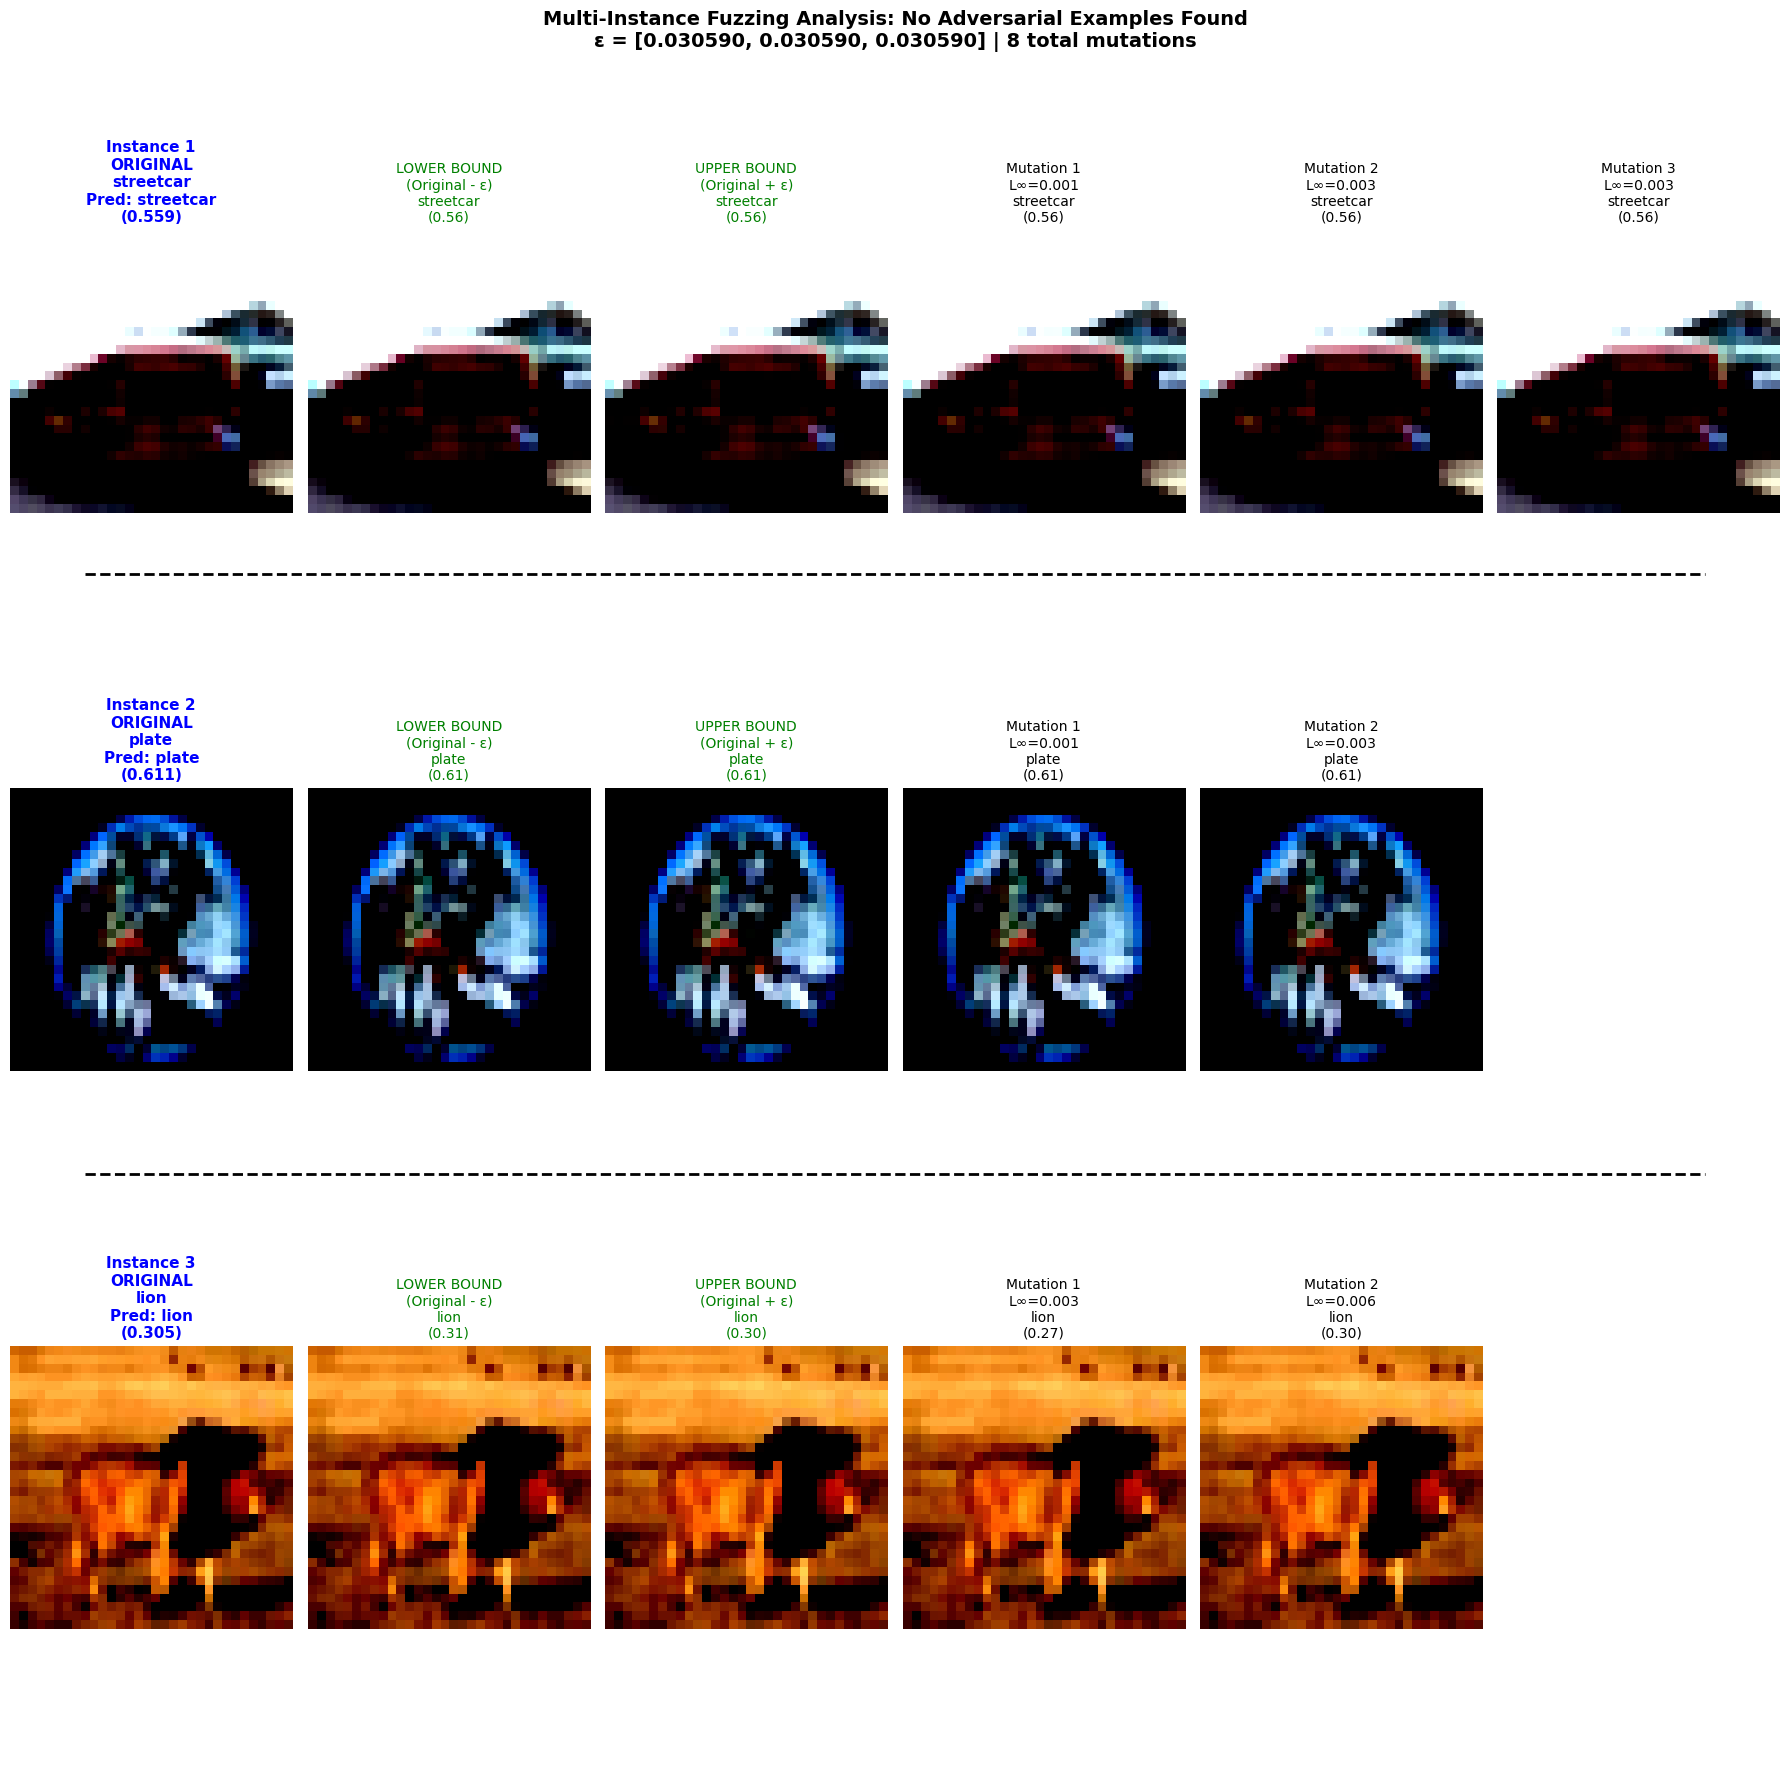


💡 Observations:
  - Tested 3 instances with 8 total perturbation attempts
  - All attempts maintained correct classification for their respective instances
  - Model appears robust for these instances

💡 Suggestions to find counterexamples:
  1. Increase timeout (currently 60.0s)
  2. Try more instances (currently using 3 random instances)
  3. Increase gradient mutation weight (currently 0)
  4. Use GPU for faster iterations (currently: cpu)


In [3]:
# Print fuzzing summary first
print(f"\n{'='*80}")
print(f"FUZZING SUMMARY")
print(f"{'='*80}")
print(f"  Iterations: {report.total_iterations} ({report.total_iterations / report.total_time:.1f} it/s)")
print(f"  Time: {report.total_time:.2f}s")
print(f"  Seeds explored: {report.seeds_explored}")
print(f"  Neuron coverage: {report.neuron_coverage:.2%}")
print(f"  Counterexamples: {len(report.counterexamples)}")
print(f"{'='*80}\n")

# Analyze each instance
print(f"{'='*80}")
print(f"ORIGINAL INPUTS ANALYSIS")
print(f"{'='*80}")

# Get list of wrapped models for inference
wrapped_models_list = list(wrapped_models.values())

for info in instance_info:
    input_tensor = info['input_tensor']
    true_label = info['true_label']
    instance_idx = info['index']
    wrapped_model = wrapped_models_list[instance_idx]
    
    # Ensure input has batch dimension
    if input_tensor.dim() == 3:
        input_batch = input_tensor.unsqueeze(0)
    else:
        input_batch = input_tensor
    
    with torch.no_grad():
        orig_output = wrapped_model(input_batch)
        if isinstance(orig_output, dict):
            orig_output = orig_output['output']
        orig_pred = orig_output.argmax(dim=1).item()
        orig_probs = torch.softmax(orig_output[0], dim=0)
        orig_conf = orig_probs[orig_pred].item()
    
    status = "✓ Correct" if orig_pred == true_label else "✗ MISCLASSIFIED"
    print(f"Instance {info['index']+1}: True={CIFAR100_CLASSES[true_label]}, "
          f"Pred={CIFAR100_CLASSES[orig_pred]} ({orig_conf:.3f}) {status}")

print(f"{'='*80}\n")

# Print specification summary
print(f"{'='*80}")
print(f"SPECIFICATION SUMMARY")
print(f"{'='*80}")

for info in instance_info:
    input_spec = info['input_spec']
    epsilon = info['epsilon']
    true_label = info['true_label']
    
    print(f"\nInstance {info['index']+1} - {CIFAR100_CLASSES[true_label]}:")
    print(f"  InputSpec:")
    print(f"    Kind: {input_spec.kind}")
    print(f"    Shape: {input_spec.lb.shape}")
    print(f"    Epsilon (L∞): {epsilon:.6f}")
    print(f"    Range: [{input_spec.lb.min():.4f}, {input_spec.ub.max():.4f}]")
    print(f"  VNNLib Property:")
    print(f"    Robustness check: Y_i >= Y_{true_label} for all i ≠ {true_label}")
    print(f"    Meaning: Model should predict '{CIFAR100_CLASSES[true_label]}' for all inputs within ε={epsilon:.6f}")

print(f"\n{'='*80}\n")

# Create comprehensive visualization
if len(report.counterexamples) > 0:
    print(f"{'='*80}")
    print(f"🎯 FOUND {len(report.counterexamples)} COUNTEREXAMPLE(S)!")
    print(f"{'='*80}\n")
    
    # Show counterexample details
    print(f"COUNTEREXAMPLE DETAILS:\n")
    for idx, ce in enumerate(report.counterexamples[:10]):
        print(f"{idx+1}. {ce.kind}: True={CIFAR100_CLASSES[ce.expected]}, "
              f"Predicted={CIFAR100_CLASSES[ce.actual]}, Conf={ce.confidence:.3f}")
    
    # Visualize counterexamples grouped by original instance
    print(f"\n{'='*80}")
    print(f"COUNTEREXAMPLE VISUALIZATION")
    print(f"{'='*80}\n")
    
    num_show = min(10, len(report.counterexamples))
    fig, axes = plt.subplots(num_show, 3, figsize=(12, 4*num_show))
    if num_show == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Counterexamples Found: Original → Perturbation → Perturbed', 
                 fontsize=14, fontweight='bold')
    
    for idx in range(num_show):
        ce = report.counterexamples[idx]
        
        # Find which instance this counterexample is closest to
        perturbed = ce.input.squeeze()
        if perturbed.dim() == 1:
            perturbed = perturbed.reshape(3, 32, 32)
        
        # Find closest original
        min_dist = float('inf')
        closest_idx = 0
        for i, info in enumerate(instance_info):
            orig_tensor = info['input_tensor']
            if orig_tensor.dim() == 4:
                orig_tensor = orig_tensor.squeeze(0)
            dist = (perturbed - orig_tensor.reshape(3, 32, 32)).abs().max()
            if dist < min_dist:
                min_dist = dist
                closest_idx = i
        
        orig_info = instance_info[closest_idx]
        orig_tensor = orig_info['input_tensor']
        if orig_tensor.dim() == 4:
            orig_tensor = orig_tensor.squeeze(0)
        orig_tensor = orig_tensor.reshape(3, 32, 32)
        
        # Original image
        orig_img = orig_tensor.permute(1, 2, 0)
        orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
        
        # Perturbed image
        perturbed_img = perturbed.permute(1, 2, 0)
        perturbed_img_np = np.clip(perturbed_img.cpu().numpy(), 0, 1)
        
        # Perturbation (difference)
        diff = perturbed - orig_tensor
        diff_img = diff.permute(1, 2, 0)
        diff_img_np = diff_img.cpu().numpy()
        # Normalize diff for visualization
        diff_vis = (diff_img_np - diff_img_np.min()) / (diff_img_np.max() - diff_img_np.min() + 1e-8)
        
        # Plot original
        axes[idx, 0].imshow(orig_img_np, interpolation='nearest')
        axes[idx, 0].set_title(f'Original (Inst {closest_idx+1})\n{CIFAR100_CLASSES[ce.expected]}', 
                                fontsize=9, color='green', fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Plot perturbation
        axes[idx, 1].imshow(diff_vis, interpolation='nearest')
        l_inf = diff.abs().max().item()
        axes[idx, 1].set_title(f'Perturbation\nL∞={l_inf:.4f}', fontsize=9)
        axes[idx, 1].axis('off')
        
        # Plot perturbed
        axes[idx, 2].imshow(perturbed_img_np, interpolation='nearest')
        axes[idx, 2].set_title(f'Perturbed\n{CIFAR100_CLASSES[ce.actual]}\nConf={ce.confidence:.2f}', 
                                fontsize=9, color='red', fontweight='bold')
        axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully found adversarial examples!")

else:
    print(f"{'='*80}")
    print(f"⚠️  NO COUNTEREXAMPLES FOUND")
    print(f"{'='*80}\n")
    
    print(f"Fuzzing Summary:")
    print(f"  - Iterations: {report.total_iterations}")
    print(f"  - Seeds explored: {report.seeds_explored}")
    print(f"  - Neuron coverage: {report.neuron_coverage:.2%}")
    print(f"  - Time: {report.total_time:.1f}s\n")
    
    # Create visualization: one row per instance with larger images
    print("Creating visualization for all instances...\n")
    
    num_instances = len(instance_info)
    
    # One row per instance, showing: Original | LB | UB | 3 Attempts
    # Total 6 columns per row
    fig, axes = plt.subplots(num_instances, 6, figsize=(18, 6 * num_instances))
    if num_instances == 1:
        axes = axes.reshape(1, -1)
    
    for inst_idx, info in enumerate(instance_info):
        input_tensor = info['input_tensor']
        true_label = info['true_label']
        input_spec = info['input_spec']
        epsilon = info['epsilon']
        wrapped_model = wrapped_models_list[inst_idx]
        
        # Get corpus seeds for THIS instance's fuzzer
        instance_fuzzer = all_fuzzers[inst_idx]
        instance_corpus_seeds = list(instance_fuzzer.seed_corpus.seeds)
        
        # Ensure input_tensor is 3D (C, H, W) for visualization
        if input_tensor.dim() == 4:
            input_tensor = input_tensor.squeeze(0)
        
        # Get prediction on original (needs batch dimension)
        input_batch = input_tensor.unsqueeze(0)
        with torch.no_grad():
            orig_output = wrapped_model(input_batch)
            if isinstance(orig_output, dict):
                orig_output = orig_output['output']
            orig_pred = orig_output.argmax(dim=1).item()
            orig_probs = torch.softmax(orig_output[0], dim=0)
            orig_conf = orig_probs[orig_pred].item()
        
        # Column 0: Original
        orig_img = input_tensor.reshape(3, 32, 32).permute(1, 2, 0)
        orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
        axes[inst_idx, 0].imshow(orig_img_np, interpolation='nearest')
        axes[inst_idx, 0].set_title(f'Instance {inst_idx+1}\nORIGINAL\n{CIFAR100_CLASSES[true_label]}\n'
                                     f'Pred: {CIFAR100_CLASSES[orig_pred]}\n({orig_conf:.3f})',
                                     fontsize=11, color='blue', fontweight='bold')
        axes[inst_idx, 0].axis('off')
        
        # Column 1: Lower Bound
        lb_tensor = input_spec.lb
        if lb_tensor.dim() == 4:
            lb_tensor = lb_tensor.squeeze(0)
        lb_tensor = lb_tensor.reshape(3, 32, 32)
        lb_img = lb_tensor.permute(1, 2, 0)
        lb_img_np = np.clip(lb_img.cpu().numpy(), 0, 1)
        axes[inst_idx, 1].imshow(lb_img_np, interpolation='nearest')
        
        with torch.no_grad():
            lb_output = wrapped_model(lb_tensor.unsqueeze(0))
            if isinstance(lb_output, dict):
                lb_output = lb_output['output']
            lb_pred = lb_output.argmax(dim=1).item()
            lb_probs = torch.softmax(lb_output[0], dim=0)
            lb_conf = lb_probs[lb_pred].item()
        
        axes[inst_idx, 1].set_title(f'LOWER BOUND\n(Original - ε)\n{CIFAR100_CLASSES[lb_pred]}\n({lb_conf:.2f})',
                                     fontsize=10, color='red' if lb_pred != true_label else 'green')
        axes[inst_idx, 1].axis('off')
        
        # Column 2: Upper Bound
        ub_tensor = input_spec.ub
        if ub_tensor.dim() == 4:
            ub_tensor = ub_tensor.squeeze(0)
        ub_tensor = ub_tensor.reshape(3, 32, 32)
        ub_img = ub_tensor.permute(1, 2, 0)
        ub_img_np = np.clip(ub_img.cpu().numpy(), 0, 1)
        axes[inst_idx, 2].imshow(ub_img_np, interpolation='nearest')
        
        with torch.no_grad():
            ub_output = wrapped_model(ub_tensor.unsqueeze(0))
            if isinstance(ub_output, dict):
                ub_output = ub_output['output']
            ub_pred = ub_output.argmax(dim=1).item()
            ub_probs = torch.softmax(ub_output[0], dim=0)
            ub_conf = ub_probs[ub_pred].item()
        
        axes[inst_idx, 2].set_title(f'UPPER BOUND\n(Original + ε)\n{CIFAR100_CLASSES[ub_pred]}\n({ub_conf:.2f})',
                                     fontsize=10, color='red' if ub_pred != true_label else 'green')
        axes[inst_idx, 2].axis('off')
        
        # Columns 3-5: 3 perturbation attempts from THIS instance's corpus
        instance_seeds = []
        for seed in instance_corpus_seeds:
            seed_tensor = seed.tensor
            if seed_tensor.dim() == 4:
                seed_tensor = seed_tensor.squeeze(0)
            seed_tensor = seed_tensor.reshape(3, 32, 32)
            seed_tensor = seed_tensor.to(input_tensor.device)
            dist = (seed_tensor - input_tensor.reshape(3, 32, 32)).abs().max().item()
            if dist <= epsilon * 2:  # Within reasonable range
                instance_seeds.append((seed, dist))
        
        # Sort by distance and take closest 3 (excluding the original which has dist ~0)
        instance_seeds.sort(key=lambda x: x[1])
        # Skip seeds that are too close to the original (likely the original itself)
        instance_seeds = [s for s in instance_seeds if s[1] > 1e-6][:3]
        
        for seed_idx, (seed, dist) in enumerate(instance_seeds):
            col = 3 + seed_idx
            
            seed_tensor = seed.tensor
            if seed_tensor.dim() == 4:
                seed_tensor = seed_tensor.squeeze(0)
            seed_tensor = seed_tensor.reshape(3, 32, 32)
            img = seed_tensor.permute(1, 2, 0)
            img_np = np.clip(img.cpu().numpy(), 0, 1)
            
            # Compute perturbation from this instance's original
            seed_tensor = seed_tensor.to(input_tensor.device)
            diff = seed_tensor - input_tensor.reshape(3, 32, 32)
            l_inf = diff.abs().max().item()
            
            # Get prediction
            with torch.no_grad():
                seed_output = wrapped_model(seed_tensor.unsqueeze(0))
                if isinstance(seed_output, dict):
                    seed_output = seed_output['output']
                seed_pred = seed_output.argmax(dim=1).item()
                seed_probs = torch.softmax(seed_output[0], dim=0)
                seed_conf = seed_probs[seed_pred].item()
            
            axes[inst_idx, col].imshow(img_np, interpolation='nearest')
            title_color = 'red' if seed_pred != true_label else 'black'
            axes[inst_idx, col].set_title(f'Mutation {seed_idx+1}\nL∞={l_inf:.3f}\n'
                                          f'{CIFAR100_CLASSES[seed_pred]}\n({seed_conf:.2f})',
                                          fontsize=10, color=title_color, fontweight='bold' if seed_pred != true_label else 'normal')
            axes[inst_idx, col].axis('off')
        
        # Fill empty columns if less than 3 attempts
        for empty_col in range(3 + len(instance_seeds), 6):
            axes[inst_idx, empty_col].axis('off')
    
    # Add horizontal dash lines between rows
    for inst_idx in range(num_instances - 1):
        line_y = (inst_idx + 1) / num_instances
        fig.add_artist(plt.Line2D([0.05, 0.95], [line_y, line_y],
                                   transform=fig.transFigure, 
                                   color='black', linewidth=2, linestyle='--'))
    
    # Add epsilon annotation to title
    epsilon_list = [f"{info['epsilon']:.6f}" for info in instance_info]
    epsilon_str = f"ε = [{', '.join(epsilon_list)}]"
    
    # Count total mutations across all instances
    total_mutations = sum(len([s for s in all_fuzzers[i].seed_corpus.seeds 
    if (s.tensor.squeeze().reshape(3,32,32).to(instance_info[i]['input_tensor'].device) 
        - instance_info[i]['input_tensor'].squeeze().reshape(3,32,32)).abs().max().item() > 1e-6]) 
    for i in range(num_instances))
    
    plt.suptitle(f'Multi-Instance Fuzzing Analysis: No Adversarial Examples Found\n{epsilon_str} | {total_mutations} total mutations', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    print(f"\n💡 Observations:")
    print(f"  - Tested {len(instance_info)} instances with {total_mutations} total perturbation attempts")
    print(f"  - All attempts maintained correct classification for their respective instances")
    print(f"  - Model appears robust for these instances")
    print(f"\n💡 Suggestions to find counterexamples:")
    print(f"  1. Increase timeout (currently {config.timeout_seconds}s)")
    print(f"  2. Try more instances (currently using {len(instance_info)} random instances)")
    print(f"  3. Increase gradient mutation weight (currently {config.mutation_weights.get('gradient', 0)})")
    print(f"  4. Use GPU for faster iterations (currently: {config.device})")


## Fuzzing Trace Analysis

Analyze execution traces to understand fuzzing behavior: mutation strategies, coverage evolution, and effectiveness.

📊 Found 3 trace file(s). Starting analysis...


INSTANCE 1 - m:CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3673_sidx_32_eps_0.0039|x:cifar100_2024|s:0|is:BOX|os:TOP1_ROBUST_m0.0
✅ Loaded 188 traces from traces.json

📊 Summary Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Traces:        188
  Iterations:          0 → 1870
  Violations Found:    0
  Coverage Range:      56.1% → 56.1%
  Final Coverage:      56.1%

🔄 Mutation Strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  random          :  21 (11.2%)
  boundary        :  41 (21.8%)
  activation      :  57 (30.3%)
  pgd             :  69 (36.7%)




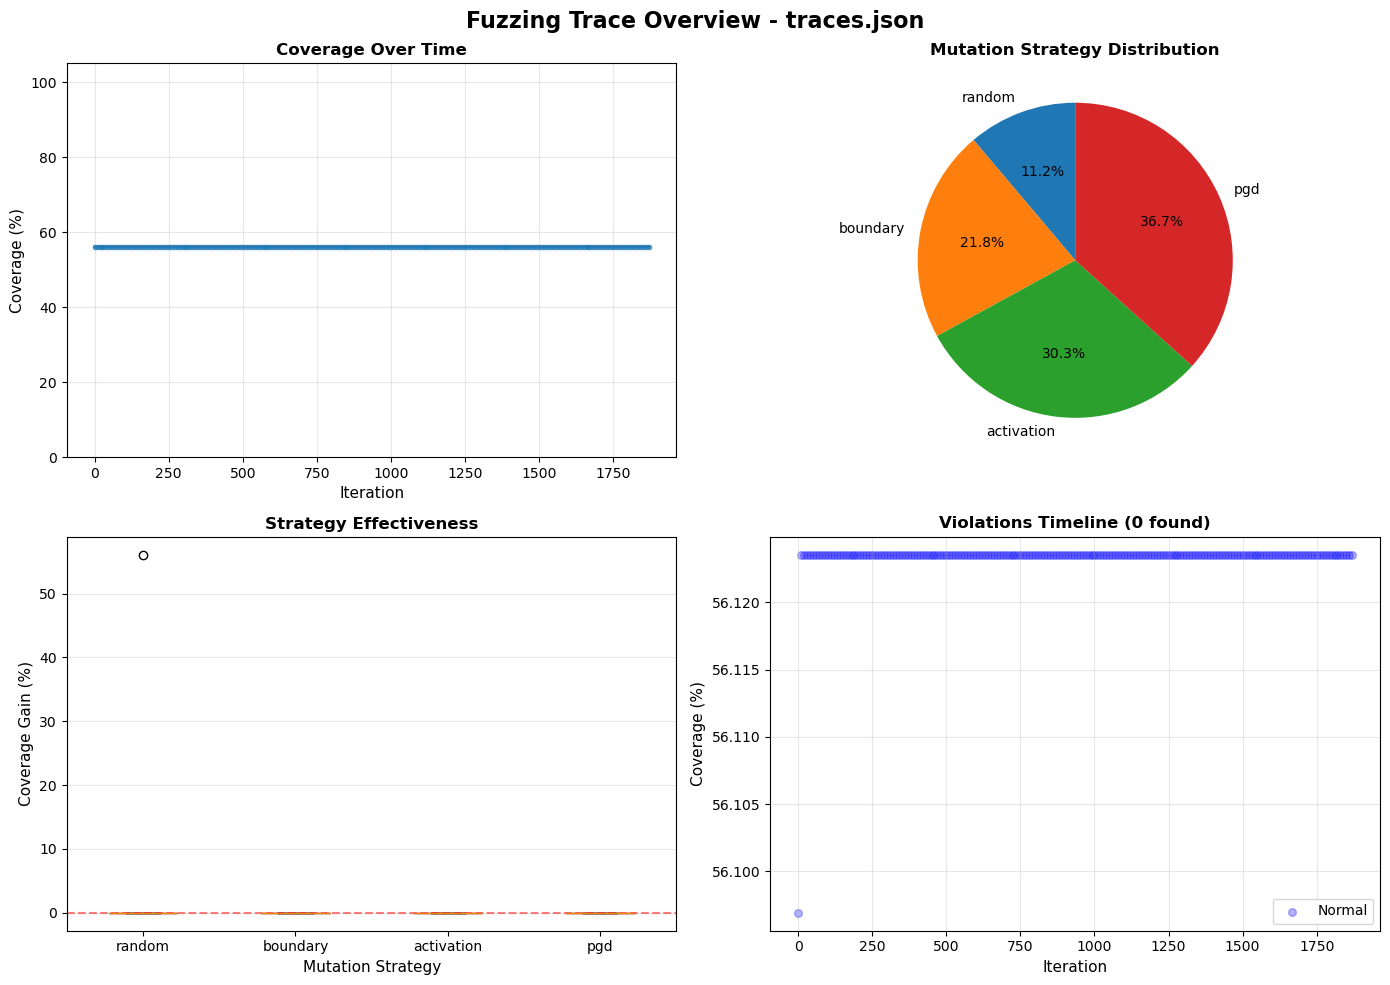


📊 Top 5 Coverage Gains:


,trace_idx,iteration,strategy,coverage,coverage_delta
0,0,0,random,0.560969,0.560969
1,1,10,boundary,0.561235,0.000000
2,2,20,boundary,0.561235,0.000000
3,3,30,activation,0.561235,0.000000
4,4,40,pgd,0.561235,0.000000



🔄 Strategy Comparison:


,Avg Gain,Std Dev,Max Gain,Count
strategy,,,,
random,0.0267,0.1224,0.561,21
activation,0.0000,0.0000,0.000,57
boundary,0.0000,0.0000,0.000,41
pgd,0.0000,0.0000,0.000,69



✅ No violations found in traces

INSTANCE 2 - m:CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4141_sidx_5393_eps_0.0039|x:cifar100_2024|s:0|is:BOX|os:TOP1_ROBUST_m0.0
✅ Loaded 188 traces from traces.json

📊 Summary Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Traces:        188
  Iterations:          0 → 1870
  Violations Found:    0
  Coverage Range:      56.1% → 56.1%
  Final Coverage:      56.1%

🔄 Mutation Strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  random          :  21 (11.2%)
  boundary        :  41 (21.8%)
  activation      :  57 (30.3%)
  pgd             :  69 (36.7%)




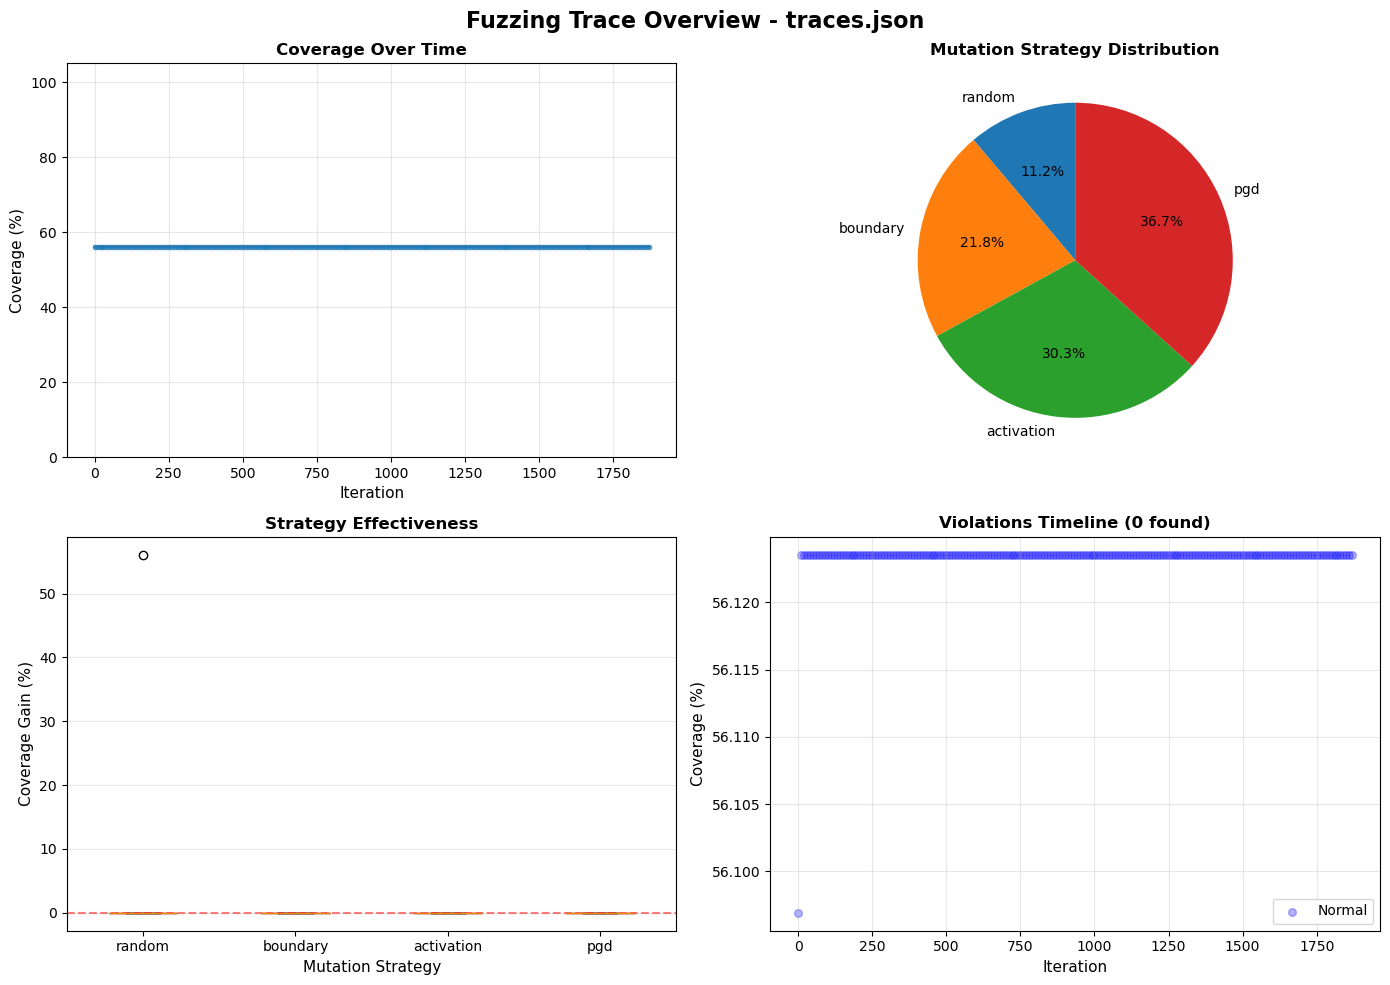


📊 Top 5 Coverage Gains:


,trace_idx,iteration,strategy,coverage,coverage_delta
0,0,0,random,0.560969,0.560969
1,1,10,boundary,0.561235,0.000000
2,2,20,boundary,0.561235,0.000000
3,3,30,activation,0.561235,0.000000
4,4,40,pgd,0.561235,0.000000



🔄 Strategy Comparison:


,Avg Gain,Std Dev,Max Gain,Count
strategy,,,,
random,0.0267,0.1224,0.561,21
activation,0.0000,0.0000,0.000,57
boundary,0.0000,0.0000,0.000,41
pgd,0.0000,0.0000,0.000,69



✅ No violations found in traces

INSTANCE 3 - m:CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_3767_sidx_7124_eps_0.0039|x:cifar100_2024|s:0|is:BOX|os:TOP1_ROBUST_m0.0
✅ Loaded 188 traces from traces.json

📊 Summary Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Traces:        188
  Iterations:          0 → 1870
  Violations Found:    0
  Coverage Range:      56.1% → 56.1%
  Final Coverage:      56.1%

🔄 Mutation Strategies
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  random          :  21 (11.2%)
  boundary        :  41 (21.8%)
  activation      :  57 (30.3%)
  pgd             :  69 (36.7%)




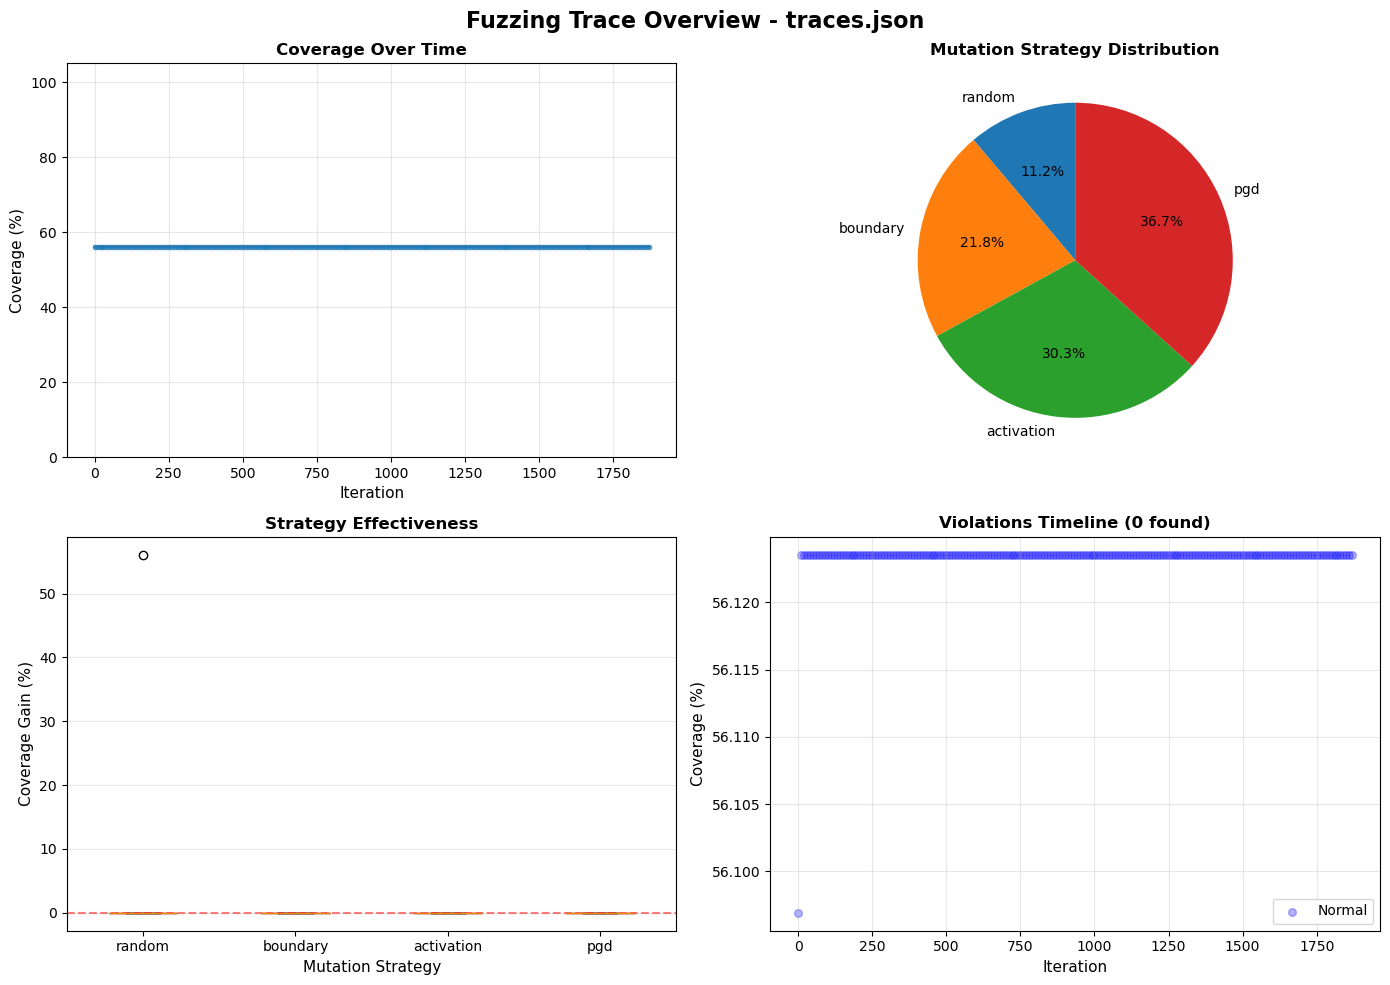


📊 Top 5 Coverage Gains:


,trace_idx,iteration,strategy,coverage,coverage_delta
0,0,0,random,0.560969,0.560969
1,1,10,boundary,0.561235,0.000000
2,2,20,boundary,0.561235,0.000000
3,3,30,activation,0.561235,0.000000
4,4,40,pgd,0.561235,0.000000



🔄 Strategy Comparison:


,Avg Gain,Std Dev,Max Gain,Count
strategy,,,,
random,0.0267,0.1224,0.561,21
activation,0.0000,0.0000,0.000,57
boundary,0.0000,0.0000,0.000,41
pgd,0.0000,0.0000,0.000,69



✅ No violations found in traces


AGGREGATE TRACE ANALYSIS - ALL INSTANCES

📊 Combined Statistics:
   Total traces: 564
   Total iterations: 1870
   Average coverage gain: 0.0030
   Max coverage gain: 0.5610

🔄 Overall Strategy Performance:


,Avg Gain,Std Dev,Max Gain,Count
strategy,,,,
random,0.0267,0.1204,0.561,63
activation,0.0000,0.0000,0.000,171
boundary,0.0000,0.0000,0.000,123
pgd,0.0000,0.0000,0.000,207



📊 Combined Strategy Distribution:


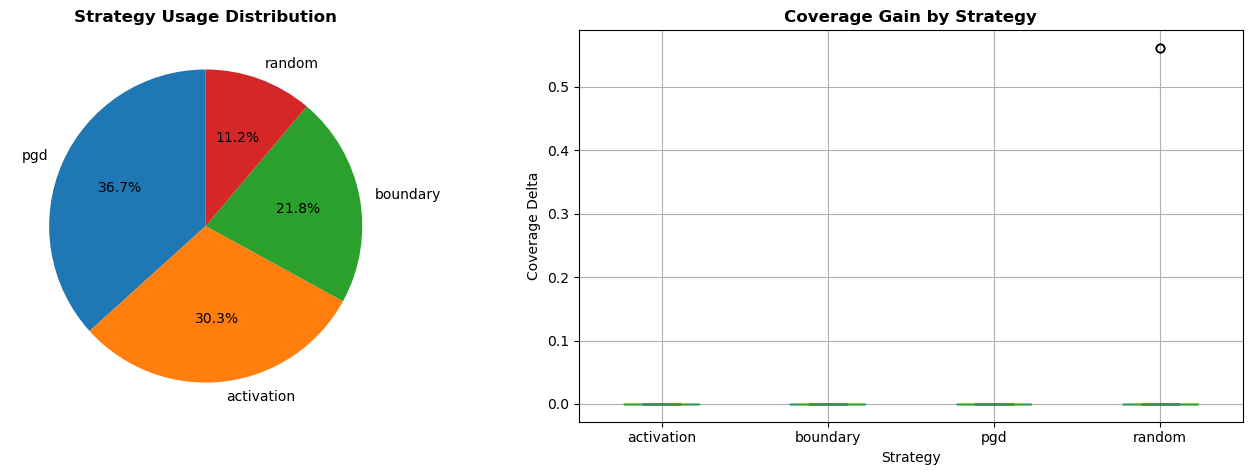


✨ Trace analysis complete!


In [4]:
# ============================================================================
# Trace Analysis: Load and visualize fuzzing execution traces
# ============================================================================

# Check if any trace files were generated
if len(trace_files) > 0:
    print(f"📊 Found {len(trace_files)} trace file(s). Starting analysis...\n")
    
    # Import trace analyzer
    from act.pipeline.fuzzing.trace_reader import TraceAnalyzer
    
    # Analyze each instance's traces
    for idx, trace_file in enumerate(trace_files):
        if not Path(trace_file).exists():
            print(f"⚠️  Warning: Trace file not found: {trace_file}")
            continue
        
        print(f"\n{'='*80}")
        print(f"INSTANCE {idx+1} - {instance_info[idx]['combo_id']}")
        print(f"{'='*80}")
        
        # Load trace analyzer
        analyzer = TraceAnalyzer(trace_file)
        
        # Show text overview
        analyzer.show_overview()
        
        print("\n")
        
        # Create visualizations
        try:
            analyzer.plot_overview()
        except Exception as e:
            print(f"⚠️  Could not generate plots: {e}")
        
        # DataFrame summary
        print(f"\n📊 Top 5 Coverage Gains:")
        df = analyzer.to_dataframe()
        if len(df) > 0:
            top_traces = df.nlargest(min(5, len(df)), 'coverage_delta')[
                ['trace_idx', 'iteration', 'strategy', 'coverage', 'coverage_delta']
            ]
            display(top_traces)
        else:
            print("   No traces captured (fuzzing may have finished too quickly)")
        
        # Strategy effectiveness
        if len(df) > 0:
            print(f"\n🔄 Strategy Comparison:")
            strategy_stats = df.groupby('strategy').agg({
                'coverage_delta': ['mean', 'std', 'max'],
                'trace_idx': 'count'
            }).round(4)
            strategy_stats.columns = ['Avg Gain', 'Std Dev', 'Max Gain', 'Count']
            display(strategy_stats.sort_values('Avg Gain', ascending=False))
        
        # Check for violations
        if 'violation' in df.columns:
            violations = df[df['violation'] == True]
            if len(violations) > 0:
                print(f"\n⚠️  Violation Analysis:")
                print(f"Found {len(violations)} violations:")
                display(violations[['trace_idx', 'iteration', 'strategy', 'coverage']])
            else:
                print(f"\n✅ No violations found in traces")
    
    # Aggregate analysis across all instances
    print(f"\n\n{'='*80}")
    print(f"AGGREGATE TRACE ANALYSIS - ALL INSTANCES")
    print(f"{'='*80}\n")
    
    all_dfs = []
    for trace_file in trace_files:
        if Path(trace_file).exists():
            try:
                analyzer = TraceAnalyzer(trace_file)
                df = analyzer.to_dataframe()
                all_dfs.append(df)
            except Exception as e:
                print(f"⚠️  Could not load trace: {e}")
    
    if len(all_dfs) > 0:
        # Concatenate all dataframes
        import pandas as pd
        combined_df = pd.concat(all_dfs, ignore_index=True)
        
        print(f"📊 Combined Statistics:")
        print(f"   Total traces: {len(combined_df)}")
        print(f"   Total iterations: {combined_df['iteration'].max()}")
        print(f"   Average coverage gain: {combined_df['coverage_delta'].mean():.4f}")
        print(f"   Max coverage gain: {combined_df['coverage_delta'].max():.4f}")
        
        print(f"\n🔄 Overall Strategy Performance:")
        overall_strategy_stats = combined_df.groupby('strategy').agg({
            'coverage_delta': ['mean', 'std', 'max'],
            'trace_idx': 'count'
        }).round(4)
        overall_strategy_stats.columns = ['Avg Gain', 'Std Dev', 'Max Gain', 'Count']
        display(overall_strategy_stats.sort_values('Avg Gain', ascending=False))
        
        # Plot combined strategy distribution
        print(f"\n📊 Combined Strategy Distribution:")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Pie chart
        strategy_counts = combined_df['strategy'].value_counts()
        ax1.pie(strategy_counts.values, labels=strategy_counts.index, autopct='%1.1f%%', startangle=90)
        ax1.set_title('Strategy Usage Distribution', fontsize=12, fontweight='bold')
        
        # Box plot
        combined_df.boxplot(column='coverage_delta', by='strategy', ax=ax2)
        ax2.set_title('Coverage Gain by Strategy', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Strategy')
        ax2.set_ylabel('Coverage Delta')
        plt.suptitle('')  # Remove default title
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✨ Trace analysis complete!")
    else:
        print("⚠️  No valid trace data found for aggregate analysis")
    
else:
    print("⚠️  No trace files found. Tracing may not be enabled or fuzzing completed too quickly.")
    print("💡 To enable tracing, ensure trace_level > 0 in FuzzingConfig")


In [5]:
# ============================================================================
# Interactive Trace Explorer: Widget-based trace browser
# ============================================================================

if len(trace_files) > 0:
    print(f"🔍 Launching interactive explorer for {len(trace_files)} trace file(s)...\n")
    
    from act.pipeline.fuzzing.trace_reader import TraceAnalyzer
    from ipywidgets import Dropdown, VBox, HTML
    from IPython.display import display
    
    # Create dropdown to select which instance to explore
    instance_options = [(f"Instance {i+1} - {instance_info[i]['combo_id']}", i) 
                        for i in range(len(trace_files))]
    
    instance_dropdown = Dropdown(
        options=instance_options,
        description='Select Instance:',
        style={'description_width': 'initial'}
    )
    
    # Header
    header = HTML(value="<h3 style='color: #2e7d32;'>📊 Trace Explorer</h3>")
    
    print("Select an instance from the dropdown, then use the trace explorer widget below.")
    print("You can browse all traces and export individual ones.\n")
    
    # Function to launch explorer for selected instance
    def on_instance_change(change):
        inst_idx = change['new']
        trace_file = trace_files[inst_idx]
        
        print(f"\n{'='*80}")
        print(f"Loading Interactive Explorer for Instance {inst_idx+1}")
        print(f"⏳ Loading trace file and generating widgets (this may take a moment)...")
        print(f"{'='*80}\n")
        
        if Path(trace_file).exists():
            analyzer = TraceAnalyzer(trace_file)
            analyzer.interactive_explorer()
            print(f"\n✅ Explorer loaded! Use the dropdown above to browse traces.")
        else:
            print(f"❌ Trace file not found: {trace_file}")
    
    # Display instance selector
    display(VBox([header, instance_dropdown]))
    
    # Attach handler
    instance_dropdown.observe(on_instance_change, names='value')
    
    # Don't auto-trigger - let user select first (avoids slow initial load)
    print("💡 Select an instance from the dropdown above to launch the explorer.")
    
else:
    print("⚠️  No trace files available for interactive exploration.")
    print("💡 Make sure tracing is enabled in FuzzingConfig (trace_level > 0)")


🔍 Launching interactive explorer for 3 trace file(s)...

Select an instance from the dropdown, then use the trace explorer widget below.
You can browse all traces and export individual ones.



💡 Select an instance from the dropdown above to launch the explorer.


## Interactive Trace Explorer

Use the dropdown widget below to interactively browse individual traces. Select any trace to see:
- Detailed trace information (iteration, strategy, coverage)
- Input tensor visualizations (before/after/diff heatmaps)
- One-click export functionality

**Note:** Requires `ipywidgets` package (`pip install ipywidgets`)

### Counterexample Generation by Mutation

In [6]:
# PGD-based counterexample generation
import torch.nn.functional as F

def _to_like_tensor(v, like: torch.Tensor):
    if v is None:
        return None
    if torch.is_tensor(v):
        return v.to(device=like.device, dtype=like.dtype)
    return torch.as_tensor(v, device=like.device, dtype=like.dtype)

def mutate(
    x: torch.Tensor,
    model: torch.nn.Module,
    y: int,
    *,
    eps: float | None = None,
    lb=None,
    ub=None,
    steps: int = 40,
    step_size: float | None = None,
    random_start: bool = True,
):
    """PGD attack: maximize CE loss to flip prediction.

    - If lb/ub are provided, we treat them as the feasible box and project into it.
    - Otherwise, we use an L_inf ball around x with radius eps.
    """
    x0 = x.detach()

    lb_t = _to_like_tensor(lb, x0)
    ub_t = _to_like_tensor(ub, x0)

    if lb_t is not None and ub_t is not None:
        x_low, x_high = lb_t, ub_t
    else:
        if eps is None:
            raise ValueError("eps must be provided when lb/ub are not available")
        x_low, x_high = x0 - float(eps), x0 + float(eps)

    # default step size: spread movement across the available range
    if step_size is None:
        step_size = float((x_high - x_low).abs().max()) / max(int(steps), 1)
        step_size = max(step_size, 1e-6)

    # random start inside the feasible set
    if random_start:
        x_adv = x_low + torch.rand_like(x0) * (x_high - x_low)
    else:
        x_adv = x0.clone()

    # make sure we start in-bounds
    x_adv = torch.max(torch.min(x_adv, x_high), x_low).detach()

    for _ in range(int(steps)):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        if isinstance(logits, tuple):
            logits = logits[0]
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)

        y_t = torch.full((logits.shape[0],), int(y), dtype=torch.long, device=logits.device)
        loss = F.cross_entropy(logits, y_t)

        grad = torch.autograd.grad(loss, x_adv, only_inputs=True)[0]

        # gradient ascent on loss
        x_adv = (x_adv + float(step_size) * grad.sign()).detach()

        # project back to feasible set
        x_adv = torch.max(torch.min(x_adv, x_high), x_low).detach()

    return x_adv

# Multi-start PGD to find counterexample
# Extract the wrapped model for inference
class WrappedNet(torch.nn.Module):
    def __init__(self, wrapped_model):
        super().__init__()
        self.wrapped_model = wrapped_model
    def forward(self, x):
        # Skip input and input spec layers
        layers = self.wrapped_model[2:] if "InputLayer" in type(self.wrapped_model[0]).__name__ else self.wrapped_model
        for l in layers:
            x = l(x)
        return x

# Get two models from wrapped_models_list
wrapped_model1 = wrapped_models_list[0]
wrapped_model2 = wrapped_models_list[1]

# Store results for both models
results = {}

# Process Model 1
print("="*80)
print("PROCESSING MODEL 1")
print("="*80)
model1 = WrappedNet(wrapped_model1)
model1.eval()

# Get the input specs and run multi-start PGD for model 1
input_layer1 = wrapped_model1[0]
labeled_input1 = input_layer1.labeled_input
input_spec_layer1 = wrapped_model1[1]
input_spec1 = input_spec_layer1.spec
epsilon1 = float((input_spec1.ub - input_spec1.lb).max())
true_label1 = labeled_input1.label
input_tensor1 = labeled_input1.tensor.detach().clone()

lb1 = input_spec1.lb if hasattr(input_spec1, 'lb') else None
ub1 = input_spec1.ub if hasattr(input_spec1, 'ub') else None

found_ce1 = None
for i in range(50):  # restarts
    candidate = mutate(
        input_tensor1,
        model=model1,
        y=true_label1,
        eps=epsilon1,
        lb=lb1,
        ub=ub1,
        steps=40,
        random_start=True,
    )

    with torch.no_grad():
        logits = model1(candidate)
        if isinstance(logits, tuple):
            logits = logits[0]
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)
        pred = logits.argmax(dim=1).item()

    if pred != true_label1:
        found_ce1 = candidate
        print(f"Model 1: Found counterexample at restart {i}: pred={pred} != true={true_label1}")
        break

if found_ce1 is not None:
    print("Model 1: Counterexample found!")
else:
    print("Model 1: No counterexample found.")

results['model1'] = {
    'model': model1,
    'wrapped_model': wrapped_model1,
    'input_tensor': input_tensor1,
    'true_label': true_label1,
    'found_ce': found_ce1,
    'lb': lb1,
    'ub': ub1,
    'epsilon': epsilon1
}

# Process Model 2
print("\n" + "="*80)
print("PROCESSING MODEL 2")
print("="*80)
model2 = WrappedNet(wrapped_model2)
model2.eval()

# Get the input specs and run multi-start PGD for model 2
input_layer2 = wrapped_model2[0]
labeled_input2 = input_layer2.labeled_input
input_spec_layer2 = wrapped_model2[1]
input_spec2 = input_spec_layer2.spec
epsilon2 = float((input_spec2.ub - input_spec2.lb).max())
true_label2 = labeled_input2.label
input_tensor2 = labeled_input2.tensor.detach().clone()

lb2 = input_spec2.lb if hasattr(input_spec2, 'lb') else None
ub2 = input_spec2.ub if hasattr(input_spec2, 'ub') else None

found_ce2 = None
for i in range(50):  # restarts
    candidate = mutate(
        input_tensor2,
        model=model2,
        y=true_label2,
        eps=epsilon2,
        lb=lb2,
        ub=ub2,
        steps=40,
        random_start=True,
    )

    with torch.no_grad():
        logits = model2(candidate)
        if isinstance(logits, tuple):
            logits = logits[0]
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)
        pred = logits.argmax(dim=1).item()

    if pred != true_label2:
        found_ce2 = candidate
        print(f"Model 2: Found counterexample at restart {i}: pred={pred} != true={true_label2}")
        break

if found_ce2 is not None:
    print("Model 2: Counterexample found!")
else:
    print("Model 2: No counterexample found.")

results['model2'] = {
    'model': model2,
    'wrapped_model': wrapped_model2,
    'input_tensor': input_tensor2,
    'true_label': true_label2,
    'found_ce': found_ce2,
    'lb': lb2,
    'ub': ub2,
    'epsilon': epsilon2
}

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Model 1: {'CE found' if found_ce1 is not None else 'No CE'} (true_label={true_label1})")
print(f"Model 2: {'CE found' if found_ce2 is not None else 'No CE'} (true_label={true_label2})")

PROCESSING MODEL 1
Model 1: Found counterexample at restart 0: pred=90 != true=81
Model 1: Counterexample found!

PROCESSING MODEL 2
Model 2: Found counterexample at restart 0: pred=22 != true=61
Model 2: Counterexample found!

SUMMARY
Model 1: CE found (true_label=81)
Model 2: CE found (true_label=61)



VISUALIZATION: Both Models
Model 1_original: shape=(3, 32, 32) min=-1.5151 max=2.0179 mean=0.4826 std=1.1919 finite%=100.0%
Model 1_original: display_mode=as_is display_std=0.4717
Model 1_mutated: shape=(3, 32, 32) min=-1.5304 max=2.0250 mean=0.4827 std=1.1927 finite%=100.0%
Model 1_mutated: display_mode=as_is display_std=0.4716
Model 2_original: shape=(3, 32, 32) min=-1.8824 max=1.2722 mean=-0.6828 std=0.8491 finite%=100.0%
Model 2_original: display_mode=(-1,1)->(0,1) display_std=0.3163
Model 2_mutated: shape=(3, 32, 32) min=-1.8971 max=1.2864 mean=-0.6821 std=0.8473 finite%=100.0%
Model 2_mutated: display_mode=(-1,1)->(0,1) display_std=0.3160


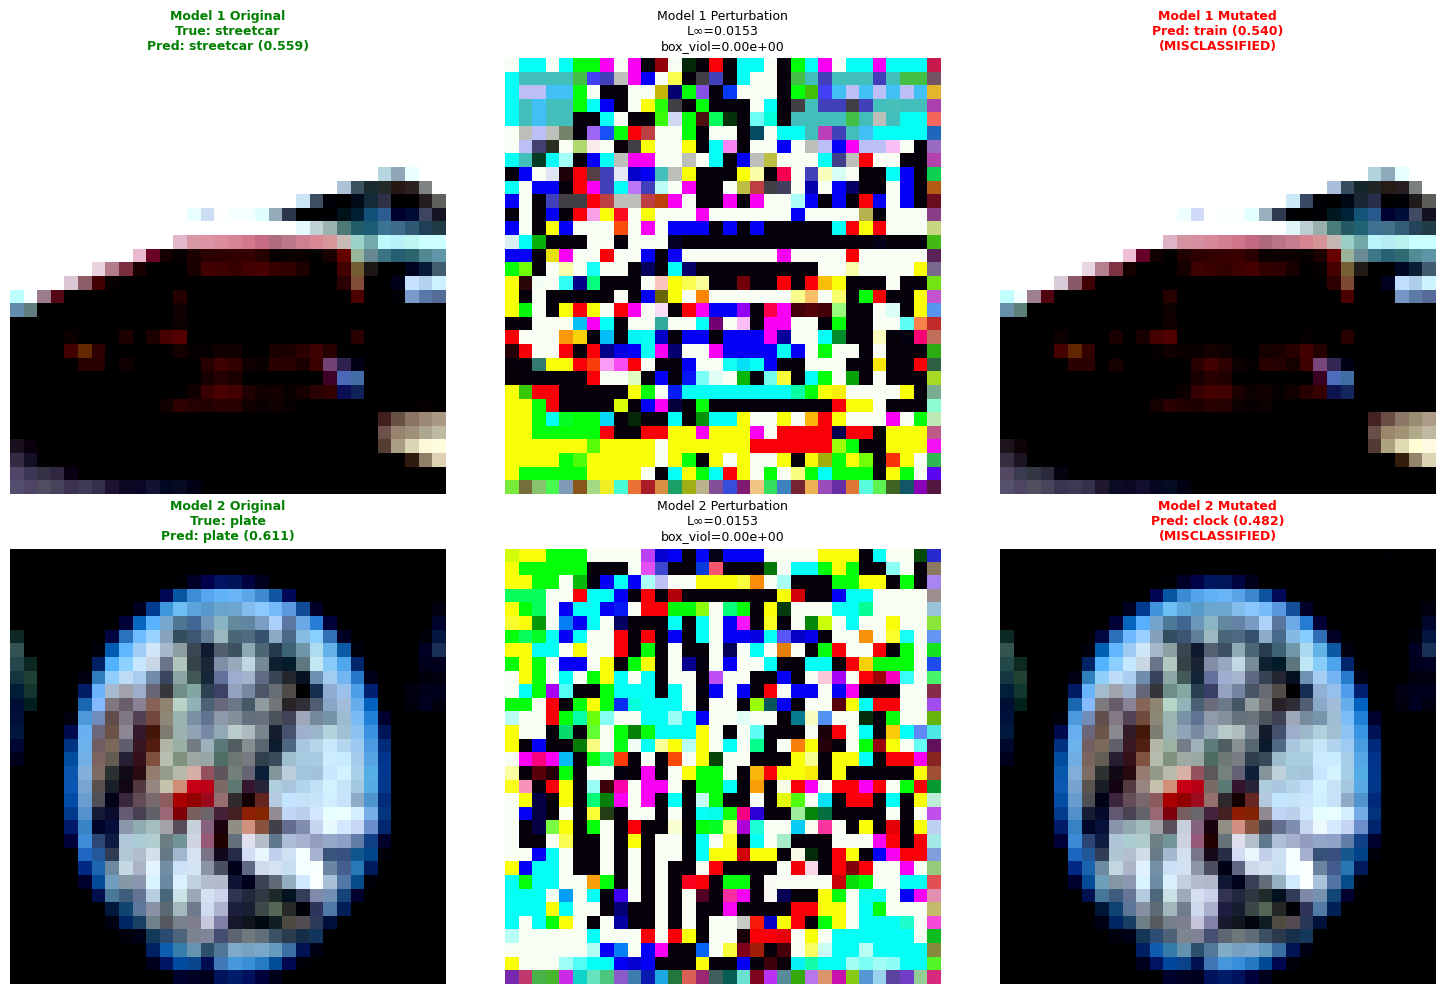

In [7]:
# Visualize original vs mutated (counterexample) images for both models
import matplotlib.pyplot as plt
import numpy as np
import torch

# Common CIFAR-100 normalization (torchvision convention)
_CIFAR100_MEAN = torch.tensor([0.5071, 0.4867, 0.4408], dtype=torch.float32)
_CIFAR100_STD = torch.tensor([0.2675, 0.2565, 0.2761], dtype=torch.float32)


def _tensor_stats(x: torch.Tensor, name: str):
    x = x.detach().float().cpu()
    if x.dim() == 4:
        x = x.squeeze(0)
    finite = torch.isfinite(x)
    finite_ratio = float(finite.float().mean().item())
    x_f = x[finite] if finite.any() else x.reshape(-1)
    if x_f.numel() == 0:
        print(f"{name}: shape={tuple(x.shape)} all-nonfinite")
        return
    print(
        f"{name}: shape={tuple(x.shape)} min={float(x_f.min().item()):.4f} max={float(x_f.max().item()):.4f} "
        f"mean={float(x_f.mean().item()):.4f} std={float(x_f.std().item()):.4f} finite%={finite_ratio*100:.1f}%"
    )


def _minmax01(chw: torch.Tensor) -> torch.Tensor:
    vmin = float(chw.min().item())
    vmax = float(chw.max().item())
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    return (chw - vmin) / denom


def _to_hwc01(img, *, name: str = "img"):
    """Convert CHW/BCHW tensor (or numpy) to HWC float in [0,1] for plt.imshow.

    Tries multiple decoding strategies and picks the one with highest contrast (std).
    Also prints debug stats so we can see why things look black.
    """
    if not torch.is_tensor(img):
        arr = np.asarray(img).astype(np.float32, copy=False)
        if arr.max() > 1.5:
            arr = arr / 255.0
        else:
            vmin = float(arr.min())
            vmax = float(arr.max())
            if vmin < 0.0 or vmax > 1.0:
                denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
                arr = (arr - vmin) / denom
        arr = np.clip(arr, 0.0, 1.0)
        return arr

    t = img.detach().float().cpu()
    if t.dim() == 4:
        t = t.squeeze(0)

    _tensor_stats(t, name)

    # Ensure CHW if possible
    chw = t
    if chw.dim() == 3 and chw.shape[0] not in (1, 3) and chw.shape[-1] in (1, 3):
        # HWC -> CHW
        chw = chw.permute(2, 0, 1)

    candidates = []

    if chw.dim() == 3 and chw.shape[0] == 3:
        vmin = float(chw.min().item())
        vmax = float(chw.max().item())

        # 1) assume [0,255]
        if vmax > 1.5:
            candidates.append(("/255", (chw / 255.0).clamp(0, 1)))

        # 2) assume already [0,1]
        candidates.append(("as_is", chw.clamp(0, 1)))

        # 3) CIFAR100 de-norm
        mean = _CIFAR100_MEAN.view(3, 1, 1)
        std = _CIFAR100_STD.view(3, 1, 1)
        candidates.append(("cifar_denorm", (chw * std + mean).clamp(0, 1)))

        # 4) [-1,1] -> [0,1]
        candidates.append(("(-1,1)->(0,1)", ((chw + 1.0) / 2.0).clamp(0, 1)))

        # 5) min-max
        candidates.append(("minmax", _minmax01(chw).clamp(0, 1)))

        # Pick most contrasty (avoid all-black)
        best_name, best = None, None
        best_score = -1.0
        for nm, cand in candidates:
            cand_f = cand[torch.isfinite(cand)]
            score = float(cand_f.std().item()) if cand_f.numel() else -1.0
            if score > best_score:
                best_score = score
                best_name, best = nm, cand

        print(f"{name}: display_mode={best_name} display_std={best_score:.4f}")
        hwc = best.permute(1, 2, 0).numpy()
        return np.clip(hwc, 0.0, 1.0)

    # Non-3ch fallback
    arr = chw.numpy().astype(np.float32, copy=False)
    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))
    if vmax > 1.5:
        arr = arr / 255.0
    elif vmin < 0.0 or vmax > 1.0:
        denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
        arr = (arr - vmin) / denom

    if arr.ndim == 3 and arr.shape[0] in (1, 3):
        arr = np.transpose(arr, (1, 2, 0))
    elif arr.ndim == 2:
        arr = arr[..., None]

    arr = np.clip(arr, 0.0, 1.0)
    return arr


def _ensure_bchw(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 3:
        return x.unsqueeze(0)
    return x


def _get_pred_conf(x: torch.Tensor, model):
    xb = _ensure_bchw(x)
    with torch.no_grad():
        logits = model(xb)
        if isinstance(logits, dict):
            logits = logits.get('output', logits)
        if isinstance(logits, tuple):
            logits = logits[0]
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)
        probs = torch.softmax(logits[0], dim=0)
        pred = int(probs.argmax().item())
        conf = float(probs[pred].item())
    return pred, conf


def _as_chw(x: torch.Tensor) -> torch.Tensor:
    t = x.detach()
    if t.dim() == 4:
        t = t.squeeze(0)
    return t


def visualize_model_result(ax_row, model_data, model_name):
    """Visualize results for one model in a row of 3 subplots."""
    model = model_data['model']
    input_tensor = model_data['input_tensor']
    true_label = model_data['true_label']
    found_ce = model_data['found_ce']
    lb = model_data['lb']
    ub = model_data['ub']
    
    # Get class name for true label
    true_label_name = CIFAR100_CLASSES[true_label] if 0 <= true_label < len(CIFAR100_CLASSES) else str(true_label)
    
    if found_ce is None:
        # Show only original
        x0_np = _to_hwc01(input_tensor, name=f"{model_name}_original")
        ax_row[0].imshow(x0_np, interpolation="nearest")
        ax_row[0].set_title(f"{model_name}\nOriginal\nTrue: {true_label_name}", fontsize=10, fontweight='bold')
        ax_row[0].axis("off")
        
        ax_row[1].text(0.5, 0.5, "No CE found", ha='center', va='center', fontsize=12)
        ax_row[1].set_title(f"{model_name}\nNo Counterexample", fontsize=10)
        ax_row[1].axis("off")
        
        ax_row[2].axis("off")
        return
    
    x0 = input_tensor
    x1 = found_ce

    # Predictions / confidence
    orig_pred, orig_conf = _get_pred_conf(x0, model)
    mut_pred, mut_conf = _get_pred_conf(x1, model)
    
    # Get class names for predictions
    orig_pred_name = CIFAR100_CLASSES[orig_pred] if 0 <= orig_pred < len(CIFAR100_CLASSES) else str(orig_pred)
    mut_pred_name = CIFAR100_CLASSES[mut_pred] if 0 <= mut_pred < len(CIFAR100_CLASSES) else str(mut_pred)

    # Perturbation
    d = (x1.detach() - x0.detach())
    linf = float(d.abs().max().item())

    # If we have box bounds, check feasibility (should be within lb/ub)
    in_box_msg = None
    if lb is not None and ub is not None:
        lb_t = _as_chw(lb).to(device=x1.device, dtype=x1.dtype)
        ub_t = _as_chw(ub).to(device=x1.device, dtype=x1.dtype)
        x1_chw = _as_chw(x1)
        low_violation = float((lb_t - x1_chw).clamp(min=0).max().item())
        high_violation = float((x1_chw - ub_t).clamp(min=0).max().item())
        max_violation = max(low_violation, high_violation)
        in_box_msg = f"box_viol={max_violation:.2e}"

    # Difference visualization (normalize to 0..1 for display)
    d0 = _as_chw(d).float().cpu()
    if d0.dim() == 3 and d0.shape[0] in (1, 3):
        d0 = d0.permute(1, 2, 0)
    d_np = d0.numpy()
    d_vis = (d_np - d_np.min()) / (d_np.max() - d_np.min() + 1e-8)

    # Images (also prints debug stats)
    x0_np = _to_hwc01(x0, name=f"{model_name}_original")
    x1_np = _to_hwc01(x1, name=f"{model_name}_mutated")

    ax_row[0].imshow(x0_np, interpolation="nearest")
    ax_row[0].set_title(
        f"{model_name} Original\nTrue: {true_label_name}\nPred: {orig_pred_name} ({orig_conf:.3f})",
        fontsize=9,
        color='green' if orig_pred == true_label else 'red',
        fontweight='bold',
    )
    ax_row[0].axis("off")

    ax_row[1].imshow(d_vis, interpolation="nearest")
    title_mid = f"{model_name} Perturbation\nL∞={linf:.4f}"
    if in_box_msg is not None:
        title_mid += f"\n{in_box_msg}"
    ax_row[1].set_title(title_mid, fontsize=9)
    ax_row[1].axis("off")

    status = "MISCLASSIFIED" if mut_pred != true_label else "still correct"
    ax_row[2].imshow(x1_np, interpolation="nearest")
    ax_row[2].set_title(
        f"{model_name} Mutated\nPred: {mut_pred_name} ({mut_conf:.3f})\n({status})",
        fontsize=9,
        color='red' if mut_pred != true_label else 'green',
        fontweight='bold',
    )
    ax_row[2].axis("off")


# Create figure with 2 rows (one for each model) and 3 columns
print("\n" + "="*80)
print("VISUALIZATION: Both Models")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Visualize Model 1 (first row)
visualize_model_result(axes[0], results['model1'], "Model 1")

# Visualize Model 2 (second row)
visualize_model_result(axes[1], results['model2'], "Model 2")

plt.tight_layout()
plt.show()
